In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [5]:
input_dir = "convergence_results_final"
mcmc_main_swd = np.load(os.path.join(input_dir, "swd_obs.npy"))
mcmc_med_swd = np.load(os.path.join(input_dir, "swd_med.npy"))
mcmc_98_swd = np.load(os.path.join(input_dir, "swd_98.npy"))
base_swd = np.load(os.path.join(input_dir, "run_00", "base_swd_list.npy"))

mcmc_main_avg = (np.mean(mcmc_main_swd, axis=0) / base_swd[0])[:-6]
mcmc_med_avg = (np.mean(mcmc_med_swd, axis=0) / base_swd[1])[:-6]
mcmc_98_avg = (np.mean(mcmc_98_swd, axis=0) / base_swd[2])[:-6]
mcmc_main_std = np.std(mcmc_main_swd / base_swd[0], axis=0)
mcmc_med_std = np.std(mcmc_med_swd / base_swd[1], axis=0)
mcmc_98_std = np.std(mcmc_98_swd / base_swd[2], axis=0)

In [6]:
mcmc_main_avg

array([0.77817695, 0.72857549, 0.69413303, 0.55422267, 0.42632397,
       0.3442299 , 0.26991175, 0.25988724, 0.23556917, 0.14676362,
       0.11532838, 0.07744016, 0.08089053, 0.05311554, 0.04838707,
       0.03977821, 0.02986108])

In [3]:
pcn_main_swd = np.load(os.path.join(input_dir, "pcn_swd_obs_single.npy"))
pcn_main_swd

array([0.64885698, 0.64647206, 0.64055322, 0.6353333 , 0.63477221,
       0.63085687, 0.61433419, 0.598008  , 0.60229564, 0.60858042,
       0.60997221, 0.70637179, 0.76480414, 0.70651311, 0.68886239,
       0.66993902, 0.56996387, 0.53112043, 0.42392311, 0.34344785,
       0.30677938, 0.31232512, 0.33807362])

In [7]:
mcmc_main_pca = np.load(os.path.join(input_dir, "mcmc_swd_pca_obs.npy"))
mcmc_med_pca = np.load(os.path.join(input_dir, "mcmc_swd_pca_med.npy"))
mcmc_98_pca = np.load(os.path.join(input_dir, "mcmc_swd_pca_98.npy"))

In [8]:
ntrials = 10
nsamps = 23
si_swd = np.empty((ntrials, nsamps, 3))
for i in range(ntrials):
    si_samps = np.load(os.path.join(input_dir, f"run_{i:02d}", "rel_swd_array.npy"))
    si_swd[i] = si_samps

si_main = si_swd[:, :, 0]
si_med = si_swd[:, :, 1]
si_98 = si_swd[:, :, 2]
si_main_avg = np.mean(si_main, axis=0)
si_med_avg = np.mean(si_med, axis=0)
si_98_avg = np.mean(si_98, axis=0)
si_main_std = np.std(si_main, axis=0)
si_med_std = np.std(si_med, axis=0)
si_98_std = np.std(si_98, axis=0)

In [9]:
sample_no_list = [2 ** i for i in range(1, 15)]          # 2 … 16384
sample_no_list += [20000, 30000, 40000, 50000,
                60000, 70000, 80000, 90000, 100000]
sample_no_list  = sorted(set(sample_no_list))
sample_no_list = np.array(sample_no_list)

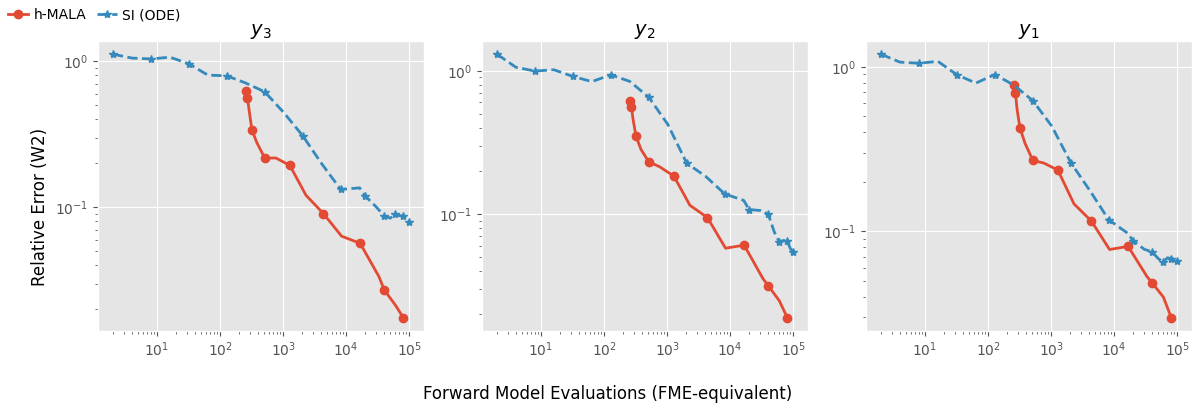

In [11]:
prior_error = 1.0  # error at 2 samples from prior-init chain, proxy for "starting at the prior"

# ---- cost conversion ----
si_fme_factor = 1.0          # SI: 1 step = 1 FME
mcmc_fme_factor = 2.0        # h-MALA: 1 cached step ~= 2 FMEs (1 forward + 1 adjoint)

# If these are currently measured in h-MALA step counts / gradient eval counts,
# convert them to FME-equivalent cost:
nevals_norm = 256
nevals_mod = 256
nevals_rare = 256
nevals_norm_fme = mcmc_fme_factor * nevals_norm
nevals_mod_fme  = mcmc_fme_factor * nevals_mod
nevals_rare_fme = mcmc_fme_factor * nevals_rare

# x-values
si_x = si_fme_factor * np.array(sample_no_list)
# mcmc_x_norm = nevals_norm_fme + mcmc_fme_factor * np.array(sample_no_list)
# mcmc_x_mod  = nevals_mod_fme  + mcmc_fme_factor * np.array(sample_no_list)
# mcmc_x_rare = nevals_rare_fme + mcmc_fme_factor * np.array(sample_no_list)
mcmc_x_norm = nevals_norm + mcmc_fme_factor * np.array(sample_no_list)[:-6]
mcmc_x_mod  = nevals_mod  + mcmc_fme_factor * np.array(sample_no_list)[:-6]
mcmc_x_rare = nevals_rare + mcmc_fme_factor * np.array(sample_no_list)[:-6]


fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# --- norm (y=0) ---
ax[2].plot(
    mcmc_x_norm, mcmc_main_avg,
    marker="o", markevery=2, linewidth=2, markersize=6
)
ax[2].plot(
    si_x, si_main_avg,
    marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2
)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y_1$", fontsize=14, pad=4)

# --- mod (y=-1) ---
ax[1].plot(
    mcmc_x_mod, mcmc_med_avg,
    marker="o", markevery=2, linewidth=2, markersize=6
)
ax[1].plot(
    si_x, si_med_avg,
    marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y_2$", fontsize=14, pad=4)

# --- rare (y=-4.2) ---
ax[0].plot(
    mcmc_x_rare, mcmc_98_avg,
    marker="o", markevery=2, linewidth=2, markersize=6, label="h-MALA"
)
ax[0].plot(
    si_x, si_98_avg,
    marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2, label="SI (ODE)"
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y_3$", fontsize=14, pad=4)

fig.supxlabel("Forward Model Evaluations (FME-equivalent)")
fig.supylabel("Relative Error (W2)")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper left",
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=1.4,
    handletextpad=0.4,
    columnspacing=0.8,
    labelspacing=0.3,
    borderaxespad=0.2,
)

plt.tight_layout()
# plt.savefig("images/lv-conv.pdf")

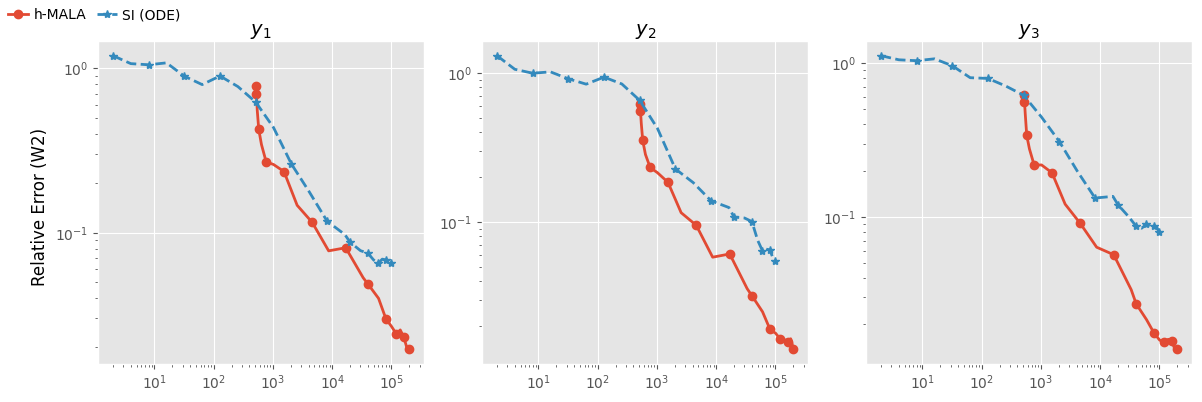

In [13]:
prior_error = 1.0  # error at 2 samples from prior-init chain

# ---- cost conversion ----
si_fme_factor = 1.0
mcmc_fme_factor = 2.0

sample_no_arr = np.array(sample_no_list)

# SI x-values
si_x = si_fme_factor * sample_no_arr

# h-MALA costs in original h-MALA step units
mcmc_steps_norm = nevals_norm + sample_no_arr
mcmc_steps_mod  = nevals_mod  + sample_no_arr
mcmc_steps_rare = nevals_rare + sample_no_arr

# h-MALA costs in FME-equivalent units
mcmc_x_norm = mcmc_fme_factor * mcmc_steps_norm
mcmc_x_mod  = mcmc_fme_factor * mcmc_steps_mod
mcmc_x_rare = mcmc_fme_factor * mcmc_steps_rare

# ---- only show h-MALA after FME / 2 threshold ----
# This filters using the original h-MALA step scale, while plotting true FME cost.
threshold_steps = sample_no_arr[0]

mask_norm = (mcmc_x_norm / 2.0) >= threshold_steps
mask_mod  = (mcmc_x_mod  / 2.0) >= threshold_steps
mask_rare = (mcmc_x_rare / 2.0) >= threshold_steps

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# --- norm (y1) ---
ax[0].plot(
    mcmc_x_norm[mask_norm],
    np.array(mcmc_main_avg)[mask_norm],
    marker="o",
    markevery=2,
    linewidth=2,
    markersize=6,
    label="h-MALA",
)
ax[0].plot(
    si_x,
    si_main_avg,
    marker="*",
    linestyle="dashed",
    linewidth=2,
    markersize=6,
    markevery=2,
    label="SI (ODE)",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y_1$", fontsize=14, pad=4)

# --- mod (y2) ---
ax[1].plot(
    mcmc_x_mod[mask_mod],
    np.array(mcmc_med_avg)[mask_mod],
    marker="o",
    markevery=2,
    linewidth=2,
    markersize=6,
)
ax[1].plot(
    si_x,
    si_med_avg,
    marker="*",
    linestyle="dashed",
    linewidth=2,
    markersize=6,
    markevery=2,
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y_2$", fontsize=14, pad=4)

# --- rare (y3) ---
ax[2].plot(
    mcmc_x_rare[mask_rare],
    np.array(mcmc_98_avg)[mask_rare],
    marker="o",
    markevery=2,
    linewidth=2,
    markersize=6,
)
ax[2].plot(
    si_x,
    si_98_avg,
    marker="*",
    linestyle="dashed",
    linewidth=2,
    markersize=6,
    markevery=2,
)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y_3$", fontsize=14, pad=4)

# fig.supxlabel("Forward Model Evaluations (FME-equivalent)")
fig.supylabel("Relative Error (W2)")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper left",
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=1.4,
    handletextpad=0.4,
    columnspacing=0.8,
    labelspacing=0.3,
    borderaxespad=0.2,
)

plt.tight_layout()
plt.savefig("images/conv_darcy.pdf", bbox_inches="tight")
plt.show()

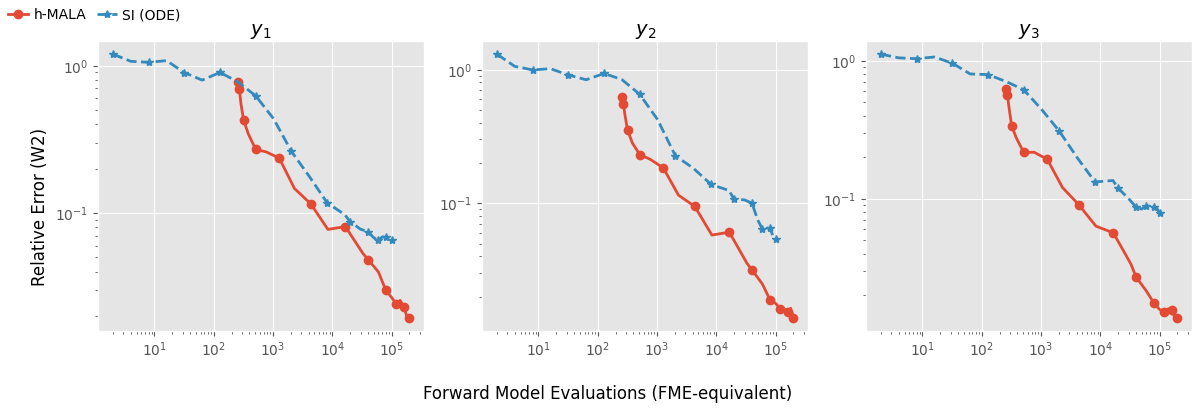

In [14]:
prior_error = 1.0  # error at 2 samples from prior-init chain

# ---- cost conversion ----
si_fme_factor = 1.0
mcmc_step_fme_factor = 2.0  # one h-MALA step ≈ 2 FMEs

sample_no_arr = np.array(sample_no_list)

# SI x-values: one SI sample/training example = 1 FME
si_x = si_fme_factor * sample_no_arr

# h-MALA x-values:
# nevals_* are already measured in FMEs, so DO NOT multiply them by 2.
# Only multiply the chain steps by 2.
mcmc_x_norm = nevals_norm + mcmc_step_fme_factor * sample_no_arr
mcmc_x_mod  = nevals_mod  + mcmc_step_fme_factor * sample_no_arr
mcmc_x_rare = nevals_rare + mcmc_step_fme_factor * sample_no_arr

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# --- norm (y1) ---
ax[0].plot(
    mcmc_x_norm,
    np.array(mcmc_main_avg),
    marker="o",
    markevery=2,
    linewidth=2,
    markersize=6,
    label="h-MALA",
)
ax[0].plot(
    si_x,
    si_main_avg,
    marker="*",
    linestyle="dashed",
    linewidth=2,
    markersize=6,
    markevery=2,
    label="SI (ODE)",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y_1$", fontsize=14, pad=4)

# --- mod (y2) ---
ax[1].plot(
    mcmc_x_mod,
    np.array(mcmc_med_avg),
    marker="o",
    markevery=2,
    linewidth=2,
    markersize=6,
)
ax[1].plot(
    si_x,
    si_med_avg,
    marker="*",
    linestyle="dashed",
    linewidth=2,
    markersize=6,
    markevery=2,
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y_2$", fontsize=14, pad=4)

# --- rare (y3) ---
ax[2].plot(
    mcmc_x_rare,
    np.array(mcmc_98_avg),
    marker="o",
    markevery=2,
    linewidth=2,
    markersize=6,
)
ax[2].plot(
    si_x,
    si_98_avg,
    marker="*",
    linestyle="dashed",
    linewidth=2,
    markersize=6,
    markevery=2,
)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y_3$", fontsize=14, pad=4)

fig.supxlabel("Forward Model Evaluations (FME-equivalent)")
fig.supylabel("Relative Error (W2)")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper left",
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=1.4,
    handletextpad=0.4,
    columnspacing=0.8,
    labelspacing=0.3,
    borderaxespad=0.2,
)

plt.tight_layout()
plt.savefig("images/conv_darcy.pdf", bbox_inches="tight")
plt.show()

In [15]:
import pickle

with open("hyperparam_results/best_hyperparams_low.pkl", "rb") as f:
    low = pickle.load(f)

In [16]:
low

{'hidden_layer': 949,
 'num_hidden_layers': 4,
 'peak_value': 0.0004754575694,
 'weight_decay': 0.0001961654235,
 'interpolant': 'trig_interpolant'}

In [23]:
with open("hyperparam_results/best_hyperparams_mid.pkl", "rb") as f:
    mid = pickle.load(f)

In [24]:
mid

{'hidden_layer': 949,
 'num_hidden_layers': 4,
 'peak_value': 0.0004754575694,
 'weight_decay': 0.0001961654235,
 'interpolant': 'trig_interpolant'}